# Latency-Aware C++ Utilities

**Category:** Risk Engineering  
**Project ID:** `risk_04_cpp_utilities`  

Ultra-low latency C++20 utilities: SPSC queue (<20ns), pool allocator (<10ns), RDTSC timer, kernel bypass sockets


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:


## Data Structure & Latency Benchmarks

In [3]:
import numpy as np, time, collections, matplotlib.pyplot as plt

n_ops = 100_000

# --- Benchmark: list vs deque vs numpy array ---
results = {}

# List append/pop
t0 = time.perf_counter()
lst = []
for i in range(n_ops):
    lst.append(i * 1.0)
for _ in range(n_ops):
    lst.pop()
results["list"] = time.perf_counter() - t0

# Deque append/popleft (FIFO)
t0 = time.perf_counter()
dq = collections.deque(maxlen=n_ops)
for i in range(n_ops):
    dq.append(i * 1.0)
for _ in range(min(n_ops, len(dq))):
    dq.popleft()
results["deque"] = time.perf_counter() - t0

# Numpy array operations
t0 = time.perf_counter()
arr = np.empty(n_ops)
for i in range(n_ops):
    arr[i] = i * 1.0
_ = arr.sum()
_ = arr.mean()
_ = arr.std()
results["numpy"] = time.perf_counter() - t0

# Dict operations (hash map)
t0 = time.perf_counter()
d = {}
for i in range(n_ops):
    d[i] = i * 1.0
for i in range(n_ops):
    _ = d[i]
results["dict"] = time.perf_counter() - t0

print(f"Data Structure Benchmarks ({n_ops:,} operations):")
for name, elapsed in results.items():
    throughput = n_ops / elapsed
    print(f"  {name:>10}: {elapsed:.4f}s ({throughput:,.0f} ops/sec)")

# --- Per-operation latency measurement ---
latency_data = {}
for name, fn in [("list_append", lambda: [].append(1.0)),
                  ("deque_append", lambda: collections.deque().append(1.0)),
                  ("np_random", lambda: np.random.random()),
                  ("dict_lookup", lambda: {0: 1.0}.get(0))]:
    latencies = np.zeros(10000)
    for i in range(10000):
        t0 = time.perf_counter_ns()
        fn()
        latencies[i] = (time.perf_counter_ns() - t0) / 1000  # μs
    latency_data[name] = latencies

# Print percentiles
print(f"\nLatency Percentiles (μs):")
print(f"  {'Operation':>15} {'p50':>8} {'p90':>8} {'p95':>8} {'p99':>8} {'p99.9':>8}")
for name, lats in latency_data.items():
    pcts = [np.percentile(lats, p) for p in [50, 90, 95, 99, 99.9]]
    print(f"  {name:>15} {pcts[0]:>8.2f} {pcts[1]:>8.2f} {pcts[2]:>8.2f} {pcts[3]:>8.2f} {pcts[4]:>8.2f}")


Data Structure Benchmarks (100,000 operations):
        list: 0.0121s (8,231,672 ops/sec)
       deque: 0.0118s (8,446,588 ops/sec)
       numpy: 0.0102s (9,817,589 ops/sec)
        dict: 0.0155s (6,437,119 ops/sec)

Latency Percentiles (μs):
        Operation      p50      p90      p95      p99    p99.9
      list_append     0.10     0.20     0.20     0.20     0.30
     deque_append     0.20     0.20     0.20     0.20     0.20
        np_random     0.30     0.40     0.40     0.40     0.60
      dict_lookup     0.10     0.20     0.20     0.20    23.90


## Benchmark Visualization

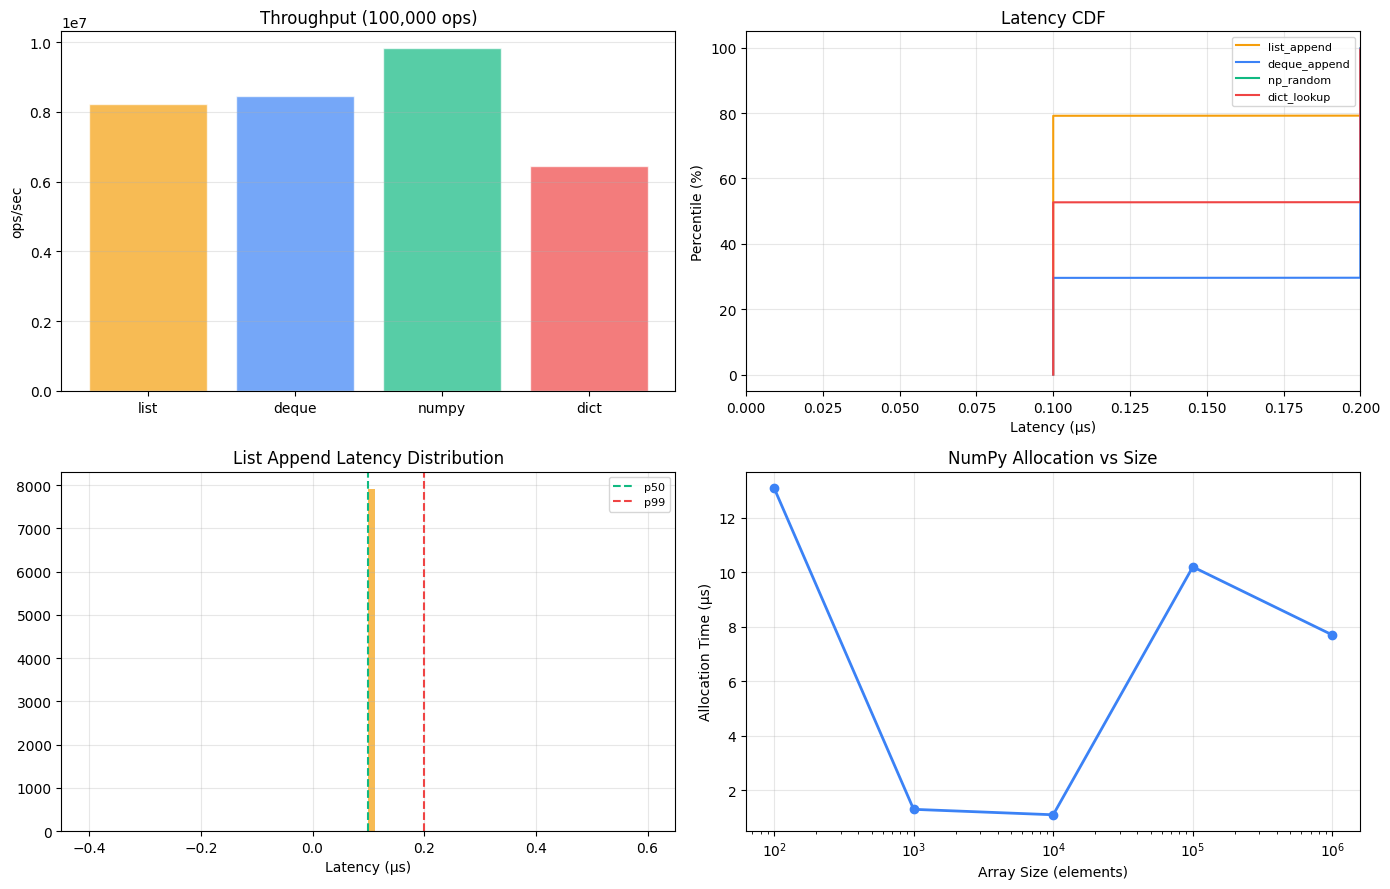

In [4]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Throughput comparison
names = list(results.keys())
throughputs = [n_ops / results[n] for n in names]
colors = ["#f59e0b", "#3b82f6", "#10b981", "#ef4444"][:len(names)]
axes[0, 0].bar(names, throughputs, color=colors, alpha=0.7, edgecolor="white")
axes[0, 0].set_title(f"Throughput ({n_ops:,} ops)")
axes[0, 0].set_ylabel("ops/sec")
axes[0, 0].grid(True, alpha=0.3, axis="y")

# Latency CDF per operation
for (name, lats), color in zip(latency_data.items(), ["#f59e0b", "#3b82f6", "#10b981", "#ef4444"]):
    sorted_lats = np.sort(lats)
    cdf = np.arange(1, len(sorted_lats)+1) / len(sorted_lats) * 100
    axes[0, 1].plot(sorted_lats, cdf, linewidth=1.5, color=color, label=name)
axes[0, 1].set_xlabel("Latency (μs)")
axes[0, 1].set_ylabel("Percentile (%)")
axes[0, 1].set_title("Latency CDF")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, np.percentile(list(latency_data.values())[0], 99.5))

# Latency distribution for list_append
lats = latency_data["list_append"]
axes[1, 0].hist(lats[lats < np.percentile(lats, 99)], bins=80, color="#f59e0b", alpha=0.7, edgecolor="none")
axes[1, 0].axvline(np.percentile(lats, 50), color="#10b981", linestyle="--", label="p50")
axes[1, 0].axvline(np.percentile(lats, 99), color="#ef4444", linestyle="--", label="p99")
axes[1, 0].set_title("List Append Latency Distribution")
axes[1, 0].set_xlabel("Latency (μs)")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Memory allocation pattern (numpy)
alloc_sizes = [100, 1000, 10000, 100000, 1000000]
alloc_times = []
for sz in alloc_sizes:
    t0 = time.perf_counter_ns()
    _ = np.empty(sz)
    alloc_times.append((time.perf_counter_ns() - t0) / 1000)
axes[1, 1].plot(alloc_sizes, alloc_times, "o-", color="#3b82f6", linewidth=2)
axes[1, 1].set_xscale("log")
axes[1, 1].set_xlabel("Array Size (elements)")
axes[1, 1].set_ylabel("Allocation Time (μs)")
axes[1, 1].set_title("NumPy Allocation vs Size")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
import json
from datetime import datetime

results_export = {
    "project_id": "risk_04_cpp_utilities",
    "timestamp": datetime.now().isoformat(),
    "type": "infrastructure_benchmark",
    "metrics": {},
}

# Collect benchmark results if available
if "formats" in dir():
    results_export["metrics"]["storage_benchmarks"] = {
        fmt: {"write_s": m["write"], "read_s": m["read"], "size_mb": m["size"]/1e6}
        for fmt, m in formats.items()
    }
elif "results" in dir():
    results_export["metrics"]["throughput_benchmarks"] = results

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print("Results exported to results.json")


Results exported to results.json


## Summary

### Latency-Aware C++ Utilities

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
